In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# import os
# from datetime import datetime
# import pandas as pd

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")

In [3]:
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [4]:
df.tail()

,Date,Temp
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7
3649,1990-12-31,13.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [6]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [7]:
df["Date"]=pd.to_datetime(df["Date"],format='%Y-%m-%d')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


In [9]:
df.set_index("Date",inplace=True)

In [10]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


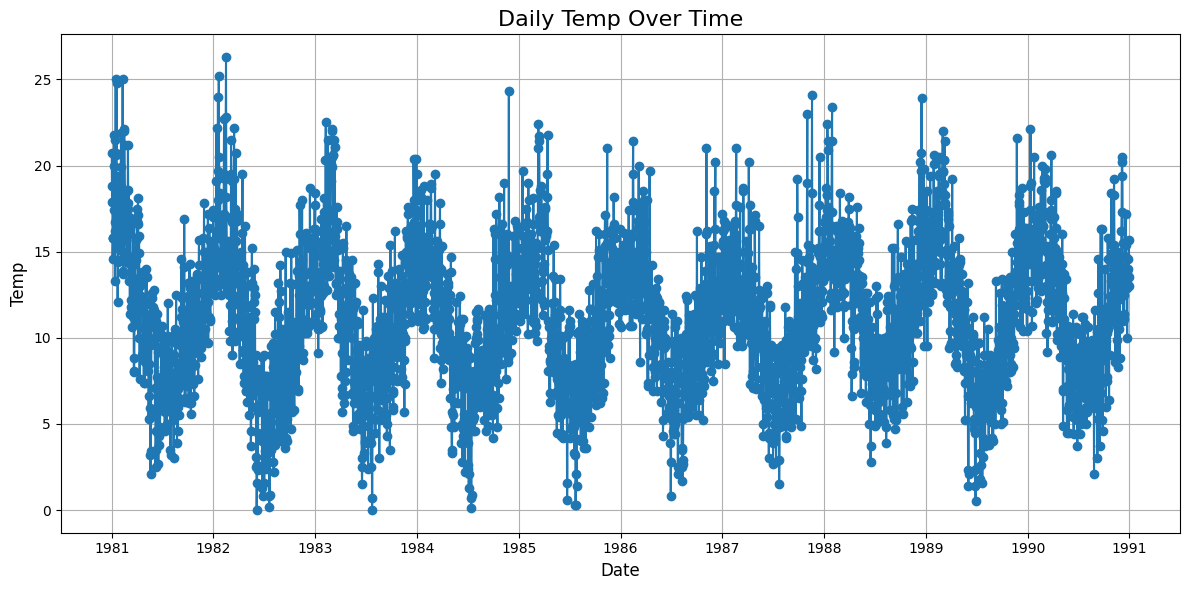

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Temp'], marker='o', linestyle='-')
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
df_1990=df["1990-01-01":"1990-12-31"]

In [13]:
df_1990

,Temp
Date,
1990-01-01,14.8
1990-01-02,13.3
1990-01-03,15.6
1990-01-04,14.5
1990-01-05,14.3
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


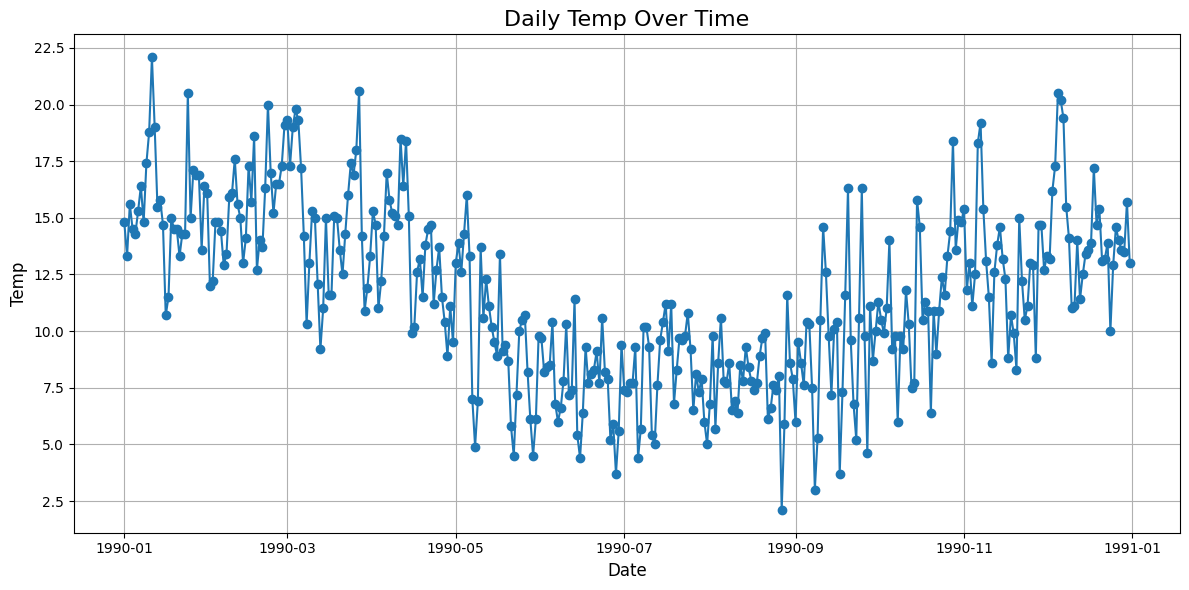

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(df_1990.index, df_1990['Temp'], marker='o', linestyle='-')
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# df_train=df["1981-01-01":"1989-12-31"]
df_train=df["1981-01-01":"1990-11-30"]

In [16]:
df_train.shape

(3619, 1)

In [17]:
df_test=df["1990-12-01":"1990-12-31"]
df_test.shape

(31, 1)

#  1. Simple Exponential Smoothing (SES)

---

##  Theory

- Simple Exponential Smoothing is used when the time series has **no trend and no seasonality**.
- It applies exponentially decreasing weights to past observations.
- **Recent observations** are weighted more heavily.
- Useful for stable series without trend or seasonality.

---

##  Formula


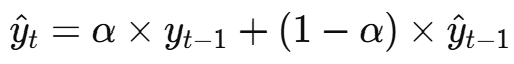

Where:
- ŷₜ = forecast for time t
- yₜ₋₁ = actual value at time t-1
- ŷₜ₋₁ = forecasted value at time t-1
- α = smoothing factor (0 < α < 1)

 If α is closer to 1 → focus more on recent observations.  
 If α is closer to 0 → focus more on older observations.


In [18]:
alpha=0.8
model = ExponentialSmoothing(
    df_train['Temp'],
    trend=None,      # no trend
    seasonal=None    # no seasonality
)

model_fit = model.fit(smoothing_level=alpha, optimized=False)
forecast = model_fit.forecast(steps=len(df_test))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [19]:
df_test['forecast'] = forecast.values


/tmp/ipython-input-807965910.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['forecast'] = forecast.values


In [20]:
df_test

,Temp,forecast
Date,,
1990-12-01,13.3,13.059268
1990-12-02,13.2,13.059268
1990-12-03,16.2,13.059268
1990-12-04,17.3,13.059268
1990-12-05,20.5,13.059268
1990-12-06,20.2,13.059268
1990-12-07,19.4,13.059268
1990-12-08,15.5,13.059268
1990-12-09,14.1,13.059268


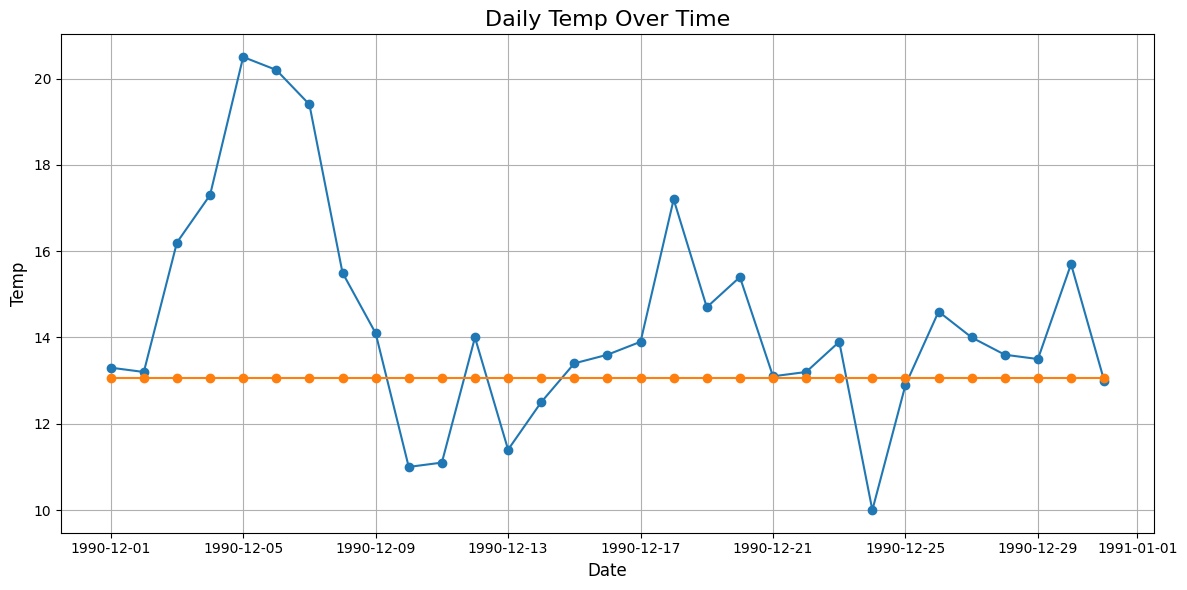

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Temp'], marker='o', linestyle='-')
plt.plot(df_test.index, df_test['forecast'],marker='o', linestyle='-')
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Double Exponential Smoothing (Holt’s Method) with Train-Test Split

---

##  Theory

- Double Exponential Smoothing is useful when the series has a **trend** but **no seasonality**.

---

##  Formula

Level:  
ℓₜ = α × yₜ + (1 - α) × (ℓₜ₋₁ + bₜ₋₁)

Trend:  
bₜ = β × (ℓₜ - ℓₜ₋₁) + (1 - β) × bₜ₋₁

Forecast:  
ŷₜ₊ₕ = ℓₜ + h × bₜ

Where:
- ℓₜ = level estimate
- bₜ = trend estimate
- ŷₜ₊ₕ = forecast for h steps ahead


In [22]:


# Apply Holt's Linear Trend Method
alpha = 0.8   # smoothing for level
beta = 0.8    # smoothing for trend



# Level only
model = ExponentialSmoothing(df_train['Temp'], trend='add', seasonal=None)
model_fit = model.fit()
forecast = model_fit.forecast(len(df_test))


# Forecast for test period
forecast = model_fit.forecast(steps=len(df_test))

# Add forecast column (avoid SettingWithCopyWarning)
df_test = df_test.copy()
df_test['Holt_Forecast'] = forecast.values


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/py

In [23]:
df_test['Holt_Forecast']

,Holt_Forecast
Date,
1990-12-01,13.119802
1990-12-02,13.118234
1990-12-03,13.116666
1990-12-04,13.115098
1990-12-05,13.113530
1990-12-06,13.111962
1990-12-07,13.110394
1990-12-08,13.108826
1990-12-09,13.107259


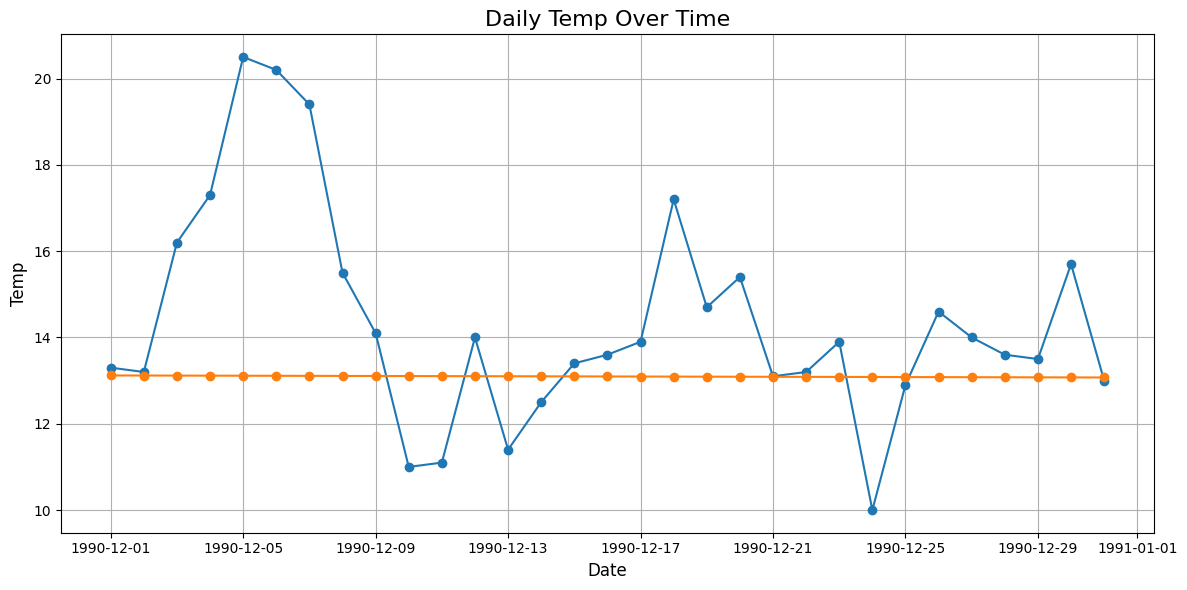

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Temp'], marker='o', linestyle='-')
plt.plot(df_test.index, df_test['Holt_Forecast'],marker='o', linestyle='-')
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
model = ExponentialSmoothing(
    df_train['Temp'],
    trend=None,
    seasonal='add',
    seasonal_periods=365  # adjust based on your data frequency
)

model_fit = model.fit(optimized=True)

# Forecast for test period
forecast = model_fit.forecast(steps=len(df_test))

# Avoid SettingWithCopyWarning
df_test = df_test.copy()
df_test['HW_Forecast'] = forecast.values

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


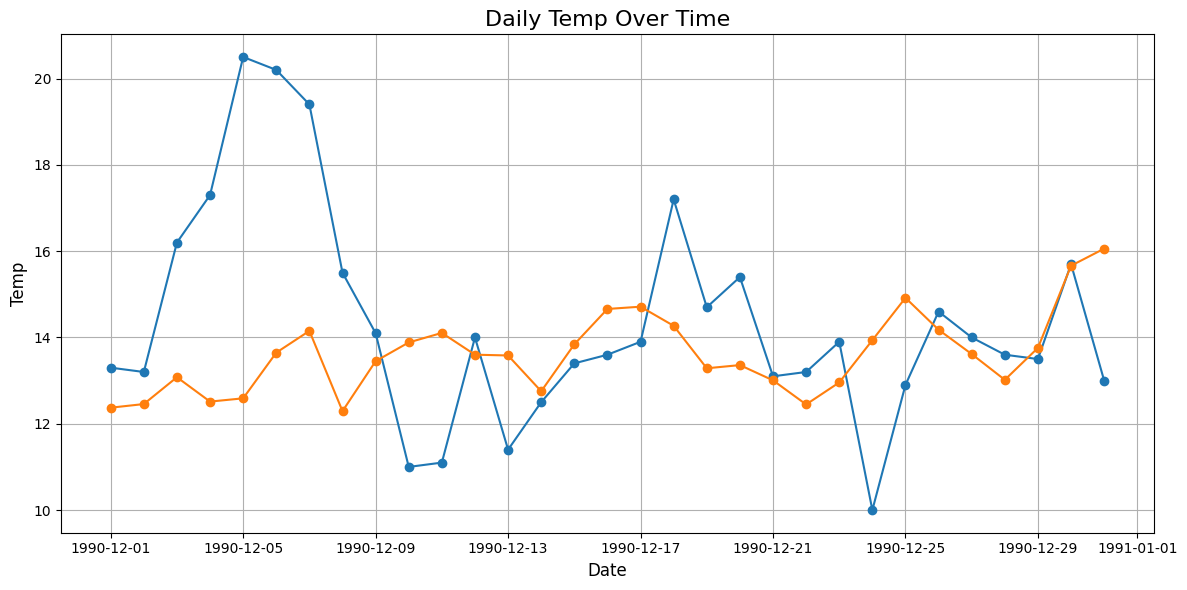

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Temp'], marker='o', linestyle='-')
plt.plot(df_test.index, df_test['HW_Forecast'],marker='o', linestyle='-')
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Rolling Holt-Winters Forecasting

1. Start with training data as initial history.  
2. Create an empty list to store forecasts.  
3. For each day in the test set:  
   - Fit Holt-Winters on current history (`trend='add'`, `seasonal='add'`, set `seasonal_periods`).  
   - Forecast 1 step ahead and save it.  
   - Append the actual test value to history.  
4. Add all forecasts to the test DataFrame.


In [27]:
len(df_test)

31

In [28]:


history = [x for x in df_train['Temp']]
predictions = []

for i in range(len(df_test)):
    model = ExponentialSmoothing(history, trend=None, seasonal='add', seasonal_periods=365)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat)
    history.append(df_test['Temp'].iloc[i])

# Create a DataFrame for results
df_result = pd.DataFrame({
    'Date': df_test.index,
    'Actual': df_test['Temp'],
    'Predicted': predictions
}).set_index('Date')



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_

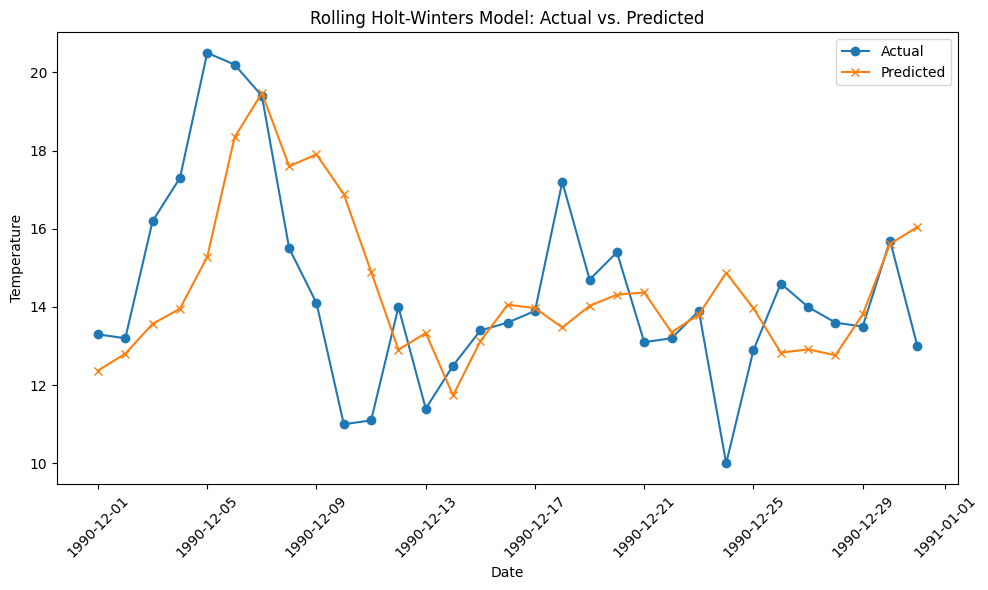

In [29]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(df_result['Actual'], label='Actual', marker='o')
plt.plot(df_result['Predicted'], label='Predicted', marker='x')
plt.title('Rolling Holt-Winters Model: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rolling_holt_winters_forecast.png')



In [30]:
from sklearn.metrics import mean_absolute_error
# Calculate MAE
mae = mean_absolute_error(df_result['Actual'], df_result['Predicted'])
print(f'Mean Absolute Error (MAE): {mae:.2f}')


Mean Absolute Error (MAE): 1.76


In [31]:
# Custom function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates the Mean Absolute Percentage Error (MAPE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [32]:
mean_absolute_percentage_error(df_result['Actual'], df_result['Predicted'])

np.float64(12.893265175154362)